# TrenMax

## Context

TrenMax es una empresa recién llegada a España que ha obtenido la licencia de operar trenes en el país, necesitan hacer un análisis de mercado de la competencia para preparar precios competitivos de viajes, para ello obtuvieron la información de la competencia recopilada dentro de un dataset.

En este dataset se encuentra los viajes históricos recopilados de la empresa de la competencia, así como el precio ofertado, con ello la idea del CEO María es poder hacer un modelo predictivo que permita predecir el precio del billete de la competencia para poder ajustar de esta manera el de TrenMax cuando salga a la venta.

## Import Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler

In [2]:
# Read the dataset
df_trenmax = pd.read_csv('renfe.csv', sep=',', encoding='latin-1')

# Display the first few rows of the dataset
df_trenmax.head()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75


In [3]:
# Display the summary information of the dataset
df_trenmax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383568 entries, 0 to 383567
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   FECHA_CONSULTA  383568 non-null  object 
 1   FECHA_INICIO    383568 non-null  object 
 2   FECHA_FIN       383568 non-null  object 
 3   CIUDAD_ORIGEN   383568 non-null  object 
 4   CIUDAD_DESTINO  383568 non-null  object 
 5   TIPO_TREN       345211 non-null  object 
 6   TIPO_TARIFA     344009 non-null  object 
 7   CLASE           344000 non-null  object 
 8   PRECIO          355038 non-null  float64
dtypes: float64(1), object(8)
memory usage: 26.3+ MB


In [4]:
# Define Target variable
target_variable = 'PRECIO'

## Columns with Null Values

In [5]:
# Display all columns that contain null values
null_columns = df_trenmax.columns[df_trenmax.isnull().any()]
print("Columns with null values: ")
for col in null_columns.tolist(): print(col)

Columns with null values: 
TIPO_TREN
TIPO_TARIFA
CLASE
PRECIO


## Date Columns Management

In [6]:
# Convert FECHA_CONSULTA to datetime
df_trenmax_with_date = df_trenmax.copy()
df_trenmax_with_date['FECHA_CONSULTA'] = pd.to_datetime(df_trenmax_with_date['FECHA_CONSULTA'])

In [7]:
# Convert FECHA_INICIO to datetime
df_trenmax_with_date['FECHA_INICIO'] = pd.to_datetime(df_trenmax_with_date['FECHA_INICIO'])

In [8]:
# Convert FECHA_FIN to datetime
df_trenmax_with_date['FECHA_FIN'] = pd.to_datetime(df_trenmax_with_date['FECHA_FIN'])

In [9]:
# Display the summary information of the dataset to see the changes
df_trenmax_with_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383568 entries, 0 to 383567
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   FECHA_CONSULTA  383568 non-null  datetime64[ns]
 1   FECHA_INICIO    383568 non-null  datetime64[ns]
 2   FECHA_FIN       383568 non-null  datetime64[ns]
 3   CIUDAD_ORIGEN   383568 non-null  object        
 4   CIUDAD_DESTINO  383568 non-null  object        
 5   TIPO_TREN       345211 non-null  object        
 6   TIPO_TARIFA     344009 non-null  object        
 7   CLASE           344000 non-null  object        
 8   PRECIO          355038 non-null  float64       
dtypes: datetime64[ns](3), float64(1), object(5)
memory usage: 26.3+ MB


## Duplicate Values Management

In [10]:
# Display duplicate rows and their count
duplicate_rows = df_trenmax_with_date[df_trenmax_with_date.duplicated()]
print("Duplicate rows: ")
print(duplicate_rows)
print("Number of duplicate rows: ", duplicate_rows.shape[0])

Duplicate rows: 
            FECHA_CONSULTA        FECHA_INICIO           FECHA_FIN  \
67494  2019-04-29 23:15:13 2019-05-14 06:20:00 2019-05-14 14:25:00   
82429  2019-04-30 09:09:51 2019-05-19 17:30:00 2019-05-19 19:43:00   
88401  2019-05-15 23:37:01 2019-06-21 21:05:00 2019-06-21 23:32:00   
107458 2019-06-12 11:51:44 2019-06-16 17:30:00 2019-06-16 19:43:00   
143395 2019-08-17 03:22:19 2019-09-01 21:03:00 2019-09-01 23:28:00   
159167 2019-05-16 13:12:07 2019-06-29 21:05:00 2019-06-29 23:32:00   
170659 2019-05-15 21:26:30 2019-06-23 21:05:00 2019-06-23 23:32:00   
191339 2019-08-18 17:34:03 2019-08-23 21:03:00 2019-08-23 23:28:00   
235466 2019-06-18 23:16:29 2019-07-23 07:00:00 2019-07-23 14:25:00   
241656 2019-05-14 03:01:42 2019-07-07 21:05:00 2019-07-07 23:32:00   
242549 2019-08-14 23:43:07 2019-09-01 11:28:00 2019-09-01 16:00:00   
245026 2019-05-13 03:23:34 2019-07-01 21:05:00 2019-07-01 23:32:00   
256887 2019-06-10 01:10:54 2019-07-07 21:03:00 2019-07-07 23:28:00   
263

In [11]:
# Drop duplicate rows
df_trenmax_no_duplicates = df_trenmax_with_date.drop_duplicates()
print("Number of rows after dropping duplicates: ", df_trenmax_no_duplicates.shape[0])

Number of rows after dropping duplicates:  383544


## Generate two New Columns "TIEMPO_VIAJE" and "DIFERENCIA_INICIO_BUSQUEDA"

In [12]:
# Create "TIEMPO_VIAJE" column as the difference between FECHA_FIN and FECHA_INICIO in minutes
df_trenmax_no_duplicates['TIEMPO_VIAJE'] = (df_trenmax_no_duplicates['FECHA_FIN'] - df_trenmax_no_duplicates['FECHA_INICIO']) / np.timedelta64(1, 'm')
# Display the first few rows of the dataset with the new column
df_trenmax_no_duplicates.loc[:, ['FECHA_INICIO', 'FECHA_FIN', 'TIEMPO_VIAJE']].head()

/var/folders/l1/jhhz3wgj68j7g0x4mfq1dyfr0000gn/T/ipykernel_21810/2156430054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trenmax_no_duplicates['TIEMPO_VIAJE'] = (df_trenmax_no_duplicates['FECHA_FIN'] - df_trenmax_no_duplicates['FECHA_INICIO']) / np.timedelta64(1, 'm')


,FECHA_INICIO,FECHA_FIN,TIEMPO_VIAJE
0,2019-06-28 20:36:00,2019-06-28 23:14:00,158.0
1,2019-07-14 10:00:00,2019-07-14 13:10:00,190.0
2,2019-05-23 13:40:00,2019-05-23 16:10:00,150.0
3,2019-05-29 14:50:00,2019-05-29 22:30:00,460.0
4,2019-06-26 13:25:00,2019-06-26 16:24:00,179.0


In [13]:
# Create "DIFERENCIA_INICIO_BUSQUEDA" column as the difference between FECHA_INICIO and FECHA_CONSULTA in minutes
df_trenmax_no_duplicates['DIFERENCIA_INICIO_BUSQUEDA'] = np.where(
    df_trenmax_no_duplicates['FECHA_CONSULTA'] > df_trenmax_no_duplicates['FECHA_INICIO'],
    np.nan,
    round(
        (
            df_trenmax_no_duplicates['FECHA_INICIO'] -
            df_trenmax_no_duplicates['FECHA_CONSULTA']
        ) / np.timedelta64(1, 'm'),
        2
    )
)
# Display the first few rows of the dataset with the new column
df_trenmax_no_duplicates.loc[:, ['FECHA_CONSULTA', 'FECHA_INICIO', 'DIFERENCIA_INICIO_BUSQUEDA']].head()

/var/folders/l1/jhhz3wgj68j7g0x4mfq1dyfr0000gn/T/ipykernel_21810/546164520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trenmax_no_duplicates['DIFERENCIA_INICIO_BUSQUEDA'] = np.where(


,FECHA_CONSULTA,FECHA_INICIO,DIFERENCIA_INICIO_BUSQUEDA
0,2019-05-25 01:43:03,2019-06-28 20:36:00,50092.95
1,2019-06-22 13:05:11,2019-07-14 10:00:00,31494.82
2,2019-04-17 06:24:03,2019-05-23 13:40:00,52275.95
3,2019-05-10 21:21:59,2019-05-29 14:50:00,26968.02
4,2019-05-09 19:43:37,2019-06-26 13:25:00,68741.38


In [14]:
# Display Number of Null Values in "DIFERENCIA_INICIO_BUSQUEDA" column
null_count_diferencia = df_trenmax_no_duplicates['DIFERENCIA_INICIO_BUSQUEDA'].isnull().sum()
print("Number of null values in DIFERENCIA_INICIO_BUSQUEDA column: ", null_count_diferencia)

Number of null values in DIFERENCIA_INICIO_BUSQUEDA column:  671


## Divide date columns in different Time Units

In [15]:
# Copy the cleaned dataset to a new variable for further processing
df_trenmax_cleaned = df_trenmax_no_duplicates.copy()

In [16]:
# Extract hour, day name, day, and month from the date columns and create new columns for each

for col in ['FECHA_CONSULTA', 'FECHA_INICIO', 'FECHA_FIN']:
    df_trenmax_cleaned[col + '_HORA'] = df_trenmax_cleaned[col].dt.hour
    df_trenmax_cleaned[col + '_NOMBREDIA'] = df_trenmax_cleaned[col].dt.day_name()
    df_trenmax_cleaned[col + '_DIA'] = df_trenmax_cleaned[col].dt.day
    df_trenmax_cleaned[col + '_MES'] = df_trenmax_cleaned[col].dt.month
    
    del df_trenmax_cleaned[col]

df_trenmax_cleaned.head()

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIFERENCIA_INICIO_BUSQUEDA,FECHA_CONSULTA_HORA,FECHA_CONSULTA_NOMBREDIA,FECHA_CONSULTA_DIA,FECHA_CONSULTA_MES,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,FECHA_FIN_HORA,FECHA_FIN_NOMBREDIA,FECHA_FIN_DIA,FECHA_FIN_MES
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.0,50092.95,1,Saturday,25,5,20,Friday,28,6,23,Friday,28,6
1,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.0,31494.82,13,Saturday,22,6,10,Sunday,14,7,13,Sunday,14,7
2,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.0,52275.95,6,Wednesday,17,4,13,Thursday,23,5,16,Thursday,23,5
3,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.0,26968.02,21,Friday,10,5,14,Wednesday,29,5,22,Wednesday,29,5
4,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.0,68741.38,19,Thursday,9,5,13,Wednesday,26,6,16,Wednesday,26,6


## Determinate Null Percentage in Target Column

In [17]:
# Calculate percentage of null values in target variable
null_percentage = df_trenmax_cleaned[target_variable].isnull().mean() * 100
print(f"Percentage of null values in {target_variable}: {null_percentage:.2f}%")

Percentage of null values in PRECIO: 7.43%


## Analyze all Columns Null Rates and Define How to Manage Them in "TIPO_TREN", "TIPO_TARIFA", "CLASE"

### TIPO TREN

In [18]:
# Calculate the number of null values in "TIPO_TREN" column and the percentage of null values in it
null_count_tipo_tren = df_trenmax_cleaned['TIPO_TREN'].isnull().sum()
print("Number of null values in TIPO_TREN column: ", null_count_tipo_tren)
null_percentage_tipo_tren = null_count_tipo_tren / df_trenmax_cleaned.shape[0] * 100
print(f"Percentage of null values in TIPO_TREN column: {null_percentage_tipo_tren:.2f}%")

Number of null values in TIPO_TREN column:  38357
Percentage of null values in TIPO_TREN column: 10.00%


In [19]:
# Replace null values in "TIPO_TREN" column with "Desconocido"
df_trenmax_cleaned['TIPO_TREN'] = df_trenmax_cleaned['TIPO_TREN'].fillna('DESCONOCIDO')

In [20]:
# Calculate and Display the distribution of the categories in "TIPO_TREN" column, the count of each category, and the percentage of each category in the dataset
tipo_tren_tabla = pd.DataFrame({
    'Cantidad': df_trenmax_cleaned['TIPO_TREN'].value_counts(),
    'Porcentaje': (
        df_trenmax_cleaned['TIPO_TREN'].value_counts(normalize=True) * 100
    ).round(2)
})

tipo_tren_tabla

,Cantidad,Porcentaje
TIPO_TREN,,
AVE,236293,61.61
DESCONOCIDO,38357,10.00
ALVIA,27231,7.10
INTERCITY,17827,4.65
REGIONAL,16817,4.38
AV City,9754,2.54
MD-LD,7475,1.95
LD,5905,1.54
AVE-TGV,4593,1.20


/var/folders/l1/jhhz3wgj68j7g0x4mfq1dyfr0000gn/T/ipykernel_21810/280892510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


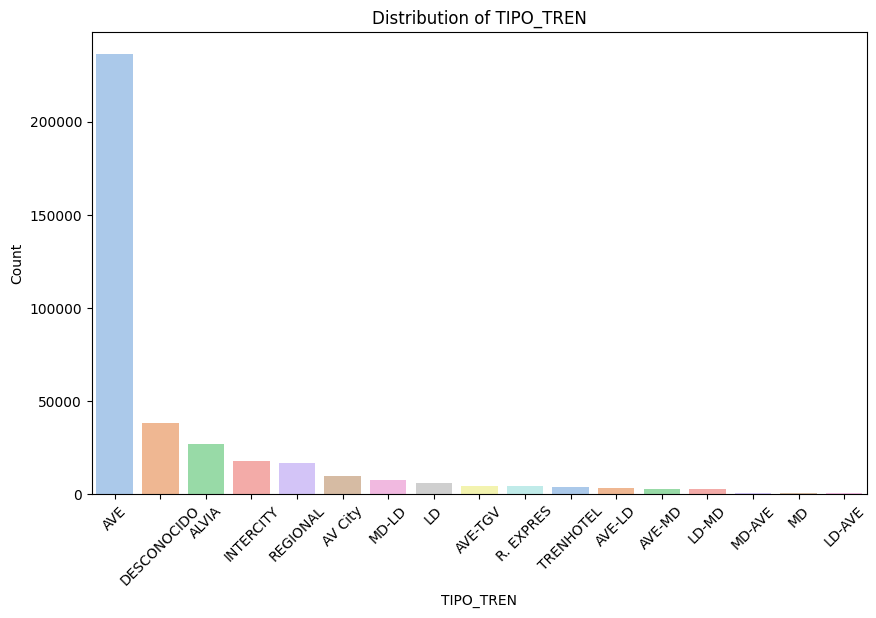

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_trenmax_cleaned,
    x='TIPO_TREN',
    order=df_trenmax_cleaned['TIPO_TREN'].value_counts().index,
    palette='pastel'
)

plt.title('Distribution of TIPO_TREN')
plt.xlabel('TIPO_TREN')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### TIPO TARIFA

In [22]:
# Calculate the number of null values in "TIPO_TARIFA" column and the percentage of null values in it
null_count_tipo_tarifa = df_trenmax_cleaned['TIPO_TARIFA'].isnull().sum()
print("Number of null values in TIPO_TARIFA column: ", null_count_tipo_tarifa)
null_percentage_tipo_tarifa = null_count_tipo_tarifa / df_trenmax_cleaned.shape[0] * 100
print(f"Percentage of null values in TIPO_TARIFA column: {null_percentage_tipo_tarifa:.2f}%")

Number of null values in TIPO_TARIFA column:  39554
Percentage of null values in TIPO_TARIFA column: 10.31%


In [23]:
# Calculate and Display the distribution of the categories in "TIPO_TARIFA" column, the count of each category, and the percentage of each category in the dataset
tipo_tarifa_tabla = pd.DataFrame({
    'Cantidad': df_trenmax_cleaned['TIPO_TARIFA'].value_counts(),
    'Porcentaje': (
        df_trenmax_cleaned['TIPO_TARIFA'].value_counts(normalize=True) * 100
    ).round(2)
})

tipo_tarifa_tabla

,Cantidad,Porcentaje
TIPO_TARIFA,,
Promo,239839,69.72
Flexible,74133,21.55
Adulto ida,21624,6.29
Promo +,8222,2.39
COD.PROMOCIONAL,148,0.04
Individual-Flexible,11,0.00
Mesa,8,0.00
Doble Familiar-Flexible,3,0.00
4x100,1,0.00


In [24]:
df_trenmax_cleaned_2 = df_trenmax_cleaned.copy()

In [25]:
import numpy as np

df_trenmax_cleaned_2['TIPO_TARIFA_AGRUPADA'] = np.select(
    [
        df_trenmax_cleaned_2['TIPO_TARIFA'].isna(),
        df_trenmax_cleaned_2['TIPO_TARIFA'].str.upper().str.contains('PROMO', na=False),
        df_trenmax_cleaned_2['TIPO_TARIFA'].str.upper().str.contains('FLEXIBLE', na=False),
        df_trenmax_cleaned_2['TIPO_TARIFA'].str.upper().str.contains('ADULTO', na=False),
    ],
    [
        'OTRAS',
        'PROMO',
        'FLEXIBLE',
        'ADULTO',
    ],
    default='OTRAS'
)

In [26]:
tabla_tipo_tarifa_agrupada = (
    df_trenmax_cleaned_2['TIPO_TARIFA_AGRUPADA']
    .value_counts(dropna=False)
    .rename_axis('TIPO_TARIFA_AGRUPADA')
    .reset_index(name='Cantidad')
)

tabla_tipo_tarifa_agrupada['Porcentaje'] = (
    tabla_tipo_tarifa_agrupada['Cantidad'] / len(df_trenmax_cleaned_2) * 100
).round(2)

tabla_tipo_tarifa_agrupada

,TIPO_TARIFA_AGRUPADA,Cantidad,Porcentaje
0,PROMO,248209,64.71
1,FLEXIBLE,74147,19.33
2,OTRAS,39564,10.32
3,ADULTO,21624,5.64


/var/folders/l1/jhhz3wgj68j7g0x4mfq1dyfr0000gn/T/ipykernel_21810/341662464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


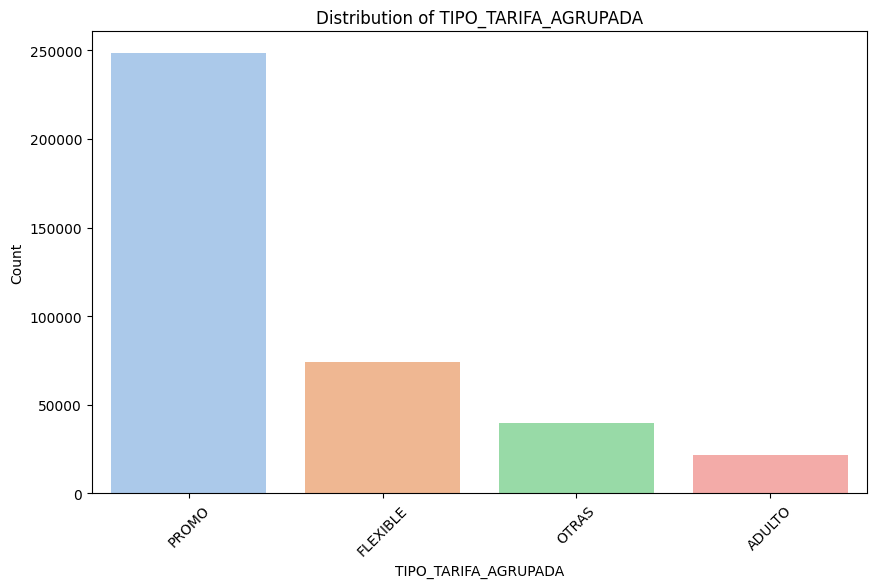

In [27]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_trenmax_cleaned_2,
    x='TIPO_TARIFA_AGRUPADA',
    order=df_trenmax_cleaned_2['TIPO_TARIFA_AGRUPADA'].value_counts().index,
    palette='pastel'
)

plt.title('Distribution of TIPO_TARIFA_AGRUPADA')
plt.xlabel('TIPO_TARIFA_AGRUPADA')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## CLASE